<a href="https://colab.research.google.com/github/hankc0215/ARIA/blob/ARIA_V2/DEM_prework.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Cell 1: 掛載 Google Drive 並安裝所需的地理空間資料處理函式庫
from google.colab import drive
drive.mount('/content/drive')

# 安裝 geopandas 和 rasterio，用於處理 SHP 和 DEM 檔案
!pip install geopandas rasterio fiona

import geopandas as gpd
import rasterio
from rasterio.mask import mask
import matplotlib.pyplot as plt
import os

Mounted at /content/drive


In [2]:
# Cell 2: 讀取 SHP 檔案，並篩選出花蓮地區的邊界

# 請將此路徑替換為您的 SHP 檔案實際路徑
# 例如：'/content/drive/MyDrive/我的地理資料/Taiwan_Boundary_County.shp'
shp_file_path = '/content/drive/MyDrive/GIS_data/TOWN_MOI_1120317.shp'

# 列出 GIS_data 目錄下的檔案，幫助您確認路徑和檔名
print("\n--- 檢查 SHP 檔案路徑 ---")
!ls -F '/content/drive/MyDrive/GIS_data/'
print("------------------------")

try:
    # 讀取 SHP 檔案，並指定編碼為 'utf-8'
    gdf = gpd.read_file(shp_file_path, encoding='utf-8')
    print("SHP 檔案已成功載入。")
    print("資料欄位：", gdf.columns.tolist())

    # 顯示前幾行資料，幫助您確認哪個欄位包含地區名稱
    print("\nSHP 資料前五行：")
    print(gdf.head())

    # 根據您的 SHP 檔案內容，篩選出花蓮地區
    # 假設地區名稱在 'COUNTYNAME' 或 'TOWNNAME' 欄位中
    # 請根據 `gdf.head()` 的輸出調整篩選條件和欄位名稱
    hualien_boundary = gdf[gdf['COUNTYNAME'] == '花蓮縣']

    if not hualien_boundary.empty:
        print("\n花蓮地區邊界已成功選取。")
        # 顯示花蓮縣的行政區數量
        print(f"花蓮地區包含 {len(hualien_boundary)} 個行政區。")
        # 可視化花蓮邊界（選用）
        # hualien_boundary.plot()
        # plt.title('Hualien County Boundary')
        # plt.show()
    else:
        print("未能從 SHP 檔案中找到 '花蓮縣'。請檢查 SHP 檔案的 'COUNTYNAME' 欄位或替換為正確的欄位名稱和值。")
        hualien_boundary = None

except Exception as e:
    print(f"載入或處理 SHP 檔案時發生錯誤：{e}")
    print("請確認檔案路徑是否正確，以及檔案是否存在於 Google Drive 中。")
    print("此外，請檢查 SHP 檔案是否包含所有必要的組件 (.shp, .shx, .dbf, .prj 等)。")



--- 檢查 SHP 檔案路徑 ---
dem_20m_hualien.tif    manifest.csv	     TOWN_MOI_1120317.prj
dem_20m.tif	       Metadata.xml	     TOWN_MOI_1120317.shp
DEM_tawiwan_V2025.tfw  TOWN_MOI_1120317.dbf  TOWN_MOI_1120317.shx
------------------------
SHP 檔案已成功載入。
資料欄位： ['TOWNID', 'TOWNCODE', 'COUNTYNAME', 'TOWNNAME', 'TOWNENG', 'COUNTYID', 'COUNTYCODE', 'geometry']

SHP 資料前五行：
  TOWNID  TOWNCODE COUNTYNAME TOWNNAME             TOWNENG COUNTYID  \
0    V02  10014020        臺東縣      成功鎮  Chenggong Township        V   
1    T21  10013210        屏東縣      佳冬鄉    Jiadong Township        T   
2    P13  10009130        雲林縣      麥寮鄉    Mailiao Township        P   
3    V11  10014110        臺東縣      綠島鄉      Ludao Township        V   
4    V16  10014160        臺東縣      蘭嶼鄉      Lanyu Township        V   

  COUNTYCODE                                           geometry  
0      10014  POLYGON ((121.40981 23.2137, 121.40984 23.2136...  
1      10013  POLYGON ((120.54845 22.46067, 120.54853 22.460...  
2      10009  

In [3]:
# Cell 3: 讀取 DEM 檔案

# 請將此路徑替換為您的 DEM 檔案實際路徑
# 例如：'/content/drive/MyDrive/我的地理資料/Taiwan_DEM.tif'
dem_file_path = '/content/drive/MyDrive/GIS_data/dem_20m.tif'


try:
    # 讀取 DEM 檔案
    with rasterio.open(dem_file_path) as src:
        dem_data = src.read(1) # 讀取第一個波段的資料
        dem_profile = src.profile # 儲存 DEM 的元資料 (metadata)
        print("DEM 檔案已成功載入。")
        print(f"DEM 影像尺寸：{dem_data.shape[1]}x{dem_data.shape[0]} 像素")
        print(f"DEM 影像的 CRS：{src.crs}")
        print(f"DEM 影像的轉換矩陣：\n{src.transform}")
        print(f"DEM 影像的無資料值：{src.nodata}")

except Exception as e:
    print(f"載入 DEM 檔案時發生錯誤：{e}")
    print("請確認檔案路徑是否正確，以及檔案是否存在於 Google Drive 中。")


--- 檢查 DEM 檔案路徑 ---
ls: cannot access '/content/drive/MyDrive/Colab_Data/DEM/': No such file or directory
------------------------
DEM 檔案已成功載入。
DEM 影像尺寸：10035x18852 像素
DEM 影像的 CRS：PROJCS["GCS_WGS_1984",GEOGCS["WGS 84",DATUM["WGS_1984",SPHEROID["WGS 84",6378137,298.25722356049,AUTHORITY["EPSG","7030"]],AUTHORITY["EPSG","6326"]],PRIMEM["Greenwich",0],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]],AUTHORITY["EPSG","4326"]],PROJECTION["Transverse_Mercator"],PARAMETER["latitude_of_origin",0],PARAMETER["central_meridian",121],PARAMETER["scale_factor",0.9999],PARAMETER["false_easting",250000],PARAMETER["false_northing",0],UNIT["metre",1,AUTHORITY["EPSG","9001"]],AXIS["Easting",EAST],AXIS["Northing",NORTH]]
DEM 影像的轉換矩陣：
| 20.00, 0.00, 150970.00|
| 0.00,-20.00, 2799170.00|
| 0.00, 0.00, 1.00|
DEM 影像的無資料值：-32767.0


DEM file successfully clipped and saved to: /content/drive/MyDrive/Colab_Data/DEM_Hualien_Clipped.tif


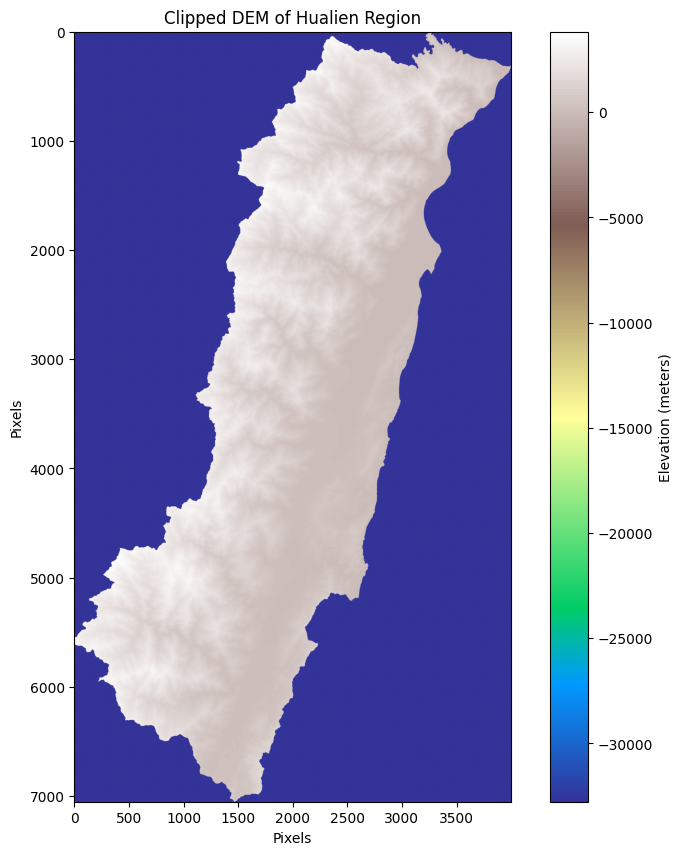

In [8]:
# Cell 4: Use Hualien boundary to clip DEM file

if 'hualien_boundary' in locals() and hualien_boundary is not None and not hualien_boundary.empty:
    if 'dem_profile' in locals() and 'dem_data' in locals():
        try:
            # Convert GeoDataFrame's CRS to DEM's CRS to ensure spatial reference consistency
            hualien_boundary_proj = hualien_boundary.to_crs(dem_profile['crs'])

            # Get GeoJSON format geometries of Hualien boundary
            geoms = [geom for geom in hualien_boundary_proj.geometry]

            # Use rasterio.mask for clipping
            with rasterio.open(dem_file_path) as src:
                out_image, out_transform = mask(src, geoms, crop=True)
                out_meta = src.meta.copy()

            out_meta.update({
                "driver": "GTiff",
                "height": out_image.shape[1],
                "width": out_image.shape[2],
                "transform": out_transform
            })

            # Set the output file path
            output_dem_path = '/content/drive/MyDrive/Colab_Data/DEM_Hualien_Clipped.tif'

            # Create output directory (if it doesn't exist)
            os.makedirs(os.path.dirname(output_dem_path), exist_ok=True)

            # Save the clipped DEM as a new GeoTIFF file
            with rasterio.open(output_dem_path, "w", **out_meta) as dest:
                dest.write(out_image)

            print(f"DEM file successfully clipped and saved to: {output_dem_path}")

            # Visualize the clipped DEM (optional)
            plt.figure(figsize=(10, 10))
            plt.imshow(out_image[0], cmap='terrain', vmin=out_image[0].min(), vmax=out_image[0].max())
            plt.colorbar(label='Elevation (meters)')
            plt.title('Clipped DEM of Hualien Region')
            plt.xlabel('Pixels')
            plt.ylabel('Pixels')
            plt.show()

        except Exception as e:
            print(f"Error while clipping DEM: {e}")
            print("Please ensure that the CRS of the SHP file and DEM file are compatible, or perform appropriate conversions.")
    else:
        print("DEM data or its metadata not successfully loaded. Please check if Cell 3 ran successfully.")
else:
    print("Hualien region boundary not successfully selected. Please check if Cell 2 ran successfully.")


Nodata value identified from clipped DEM: -32767.0
Original shape of clipped DEM data: (7054, 3998)
Number of no-data values (before processing): 16700730
Number of NaN values (after processing): 16700730
Minimum elevation (excluding NaN): -3.02 meters
Maximum elevation (excluding NaN): 3824.30 meters
Mean elevation (excluding NaN): 1219.91 meters


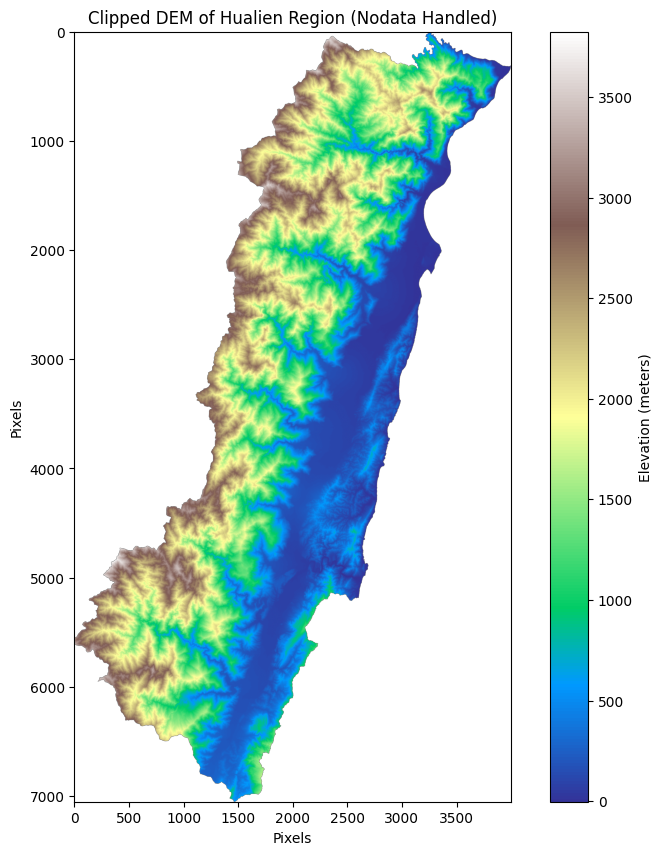

In [9]:
# Cell 5: Handle no-data values in the clipped DEM

import numpy as np

# Define the path to the clipped DEM file
clipped_dem_path = '/content/drive/MyDrive/Colab_Data/DEM_Hualien_Clipped.tif'

try:
    with rasterio.open(clipped_dem_path) as src:
        clipped_dem_data = src.read(1) # Read the first band
        nodata_value = src.nodata # Get the nodata value from metadata
        print(f"Nodata value identified from clipped DEM: {nodata_value}")

        # Replace nodata values with NaN for better handling
        clipped_dem_data_processed = clipped_dem_data.astype(float) # Ensure data type can hold NaN
        clipped_dem_data_processed[clipped_dem_data_processed == nodata_value] = np.nan

        print(f"Original shape of clipped DEM data: {clipped_dem_data.shape}")
        print(f"Number of no-data values (before processing): {(clipped_dem_data == nodata_value).sum()}")
        print(f"Number of NaN values (after processing): {np.isnan(clipped_dem_data_processed).sum()}")
        print(f"Minimum elevation (excluding NaN): {np.nanmin(clipped_dem_data_processed):.2f} meters")
        print(f"Maximum elevation (excluding NaN): {np.nanmax(clipped_dem_data_processed):.2f} meters")
        print(f"Mean elevation (excluding NaN): {np.nanmean(clipped_dem_data_processed):.2f} meters")

    # Visualize the processed DEM with NaN values handled
    plt.figure(figsize=(10, 10))
    # Use imshow with masked array or ignore nan in plotting
    plt.imshow(clipped_dem_data_processed, cmap='terrain', vmin=np.nanmin(clipped_dem_data_processed), vmax=np.nanmax(clipped_dem_data_processed))
    plt.colorbar(label='Elevation (meters)')
    plt.title('Clipped DEM of Hualien Region (Nodata Handled)')
    plt.xlabel('Pixels')
    plt.ylabel('Pixels')
    plt.show()

except Exception as e:
    print(f"Error processing clipped DEM no-data values: {e}")
    print("Please ensure the clipped DEM file exists at the specified path and is accessible.")
